# Quote-Then-Judge — Qwen2.5-14B-Instruct Re-run

This notebook repeats the full QTJ pipeline (candidate-conditioned retrieval →
training-pair construction → LoRA fine-tuning → held-out judgement) with the
**base model swapped from Qwen2.5-7B-Instruct to Qwen2.5-14B-Instruct**.

Everything else is kept identical to the validated Qwen-7B pipeline, with one
important fix baked in from the start: **fold membership is always read
directly from the `fold` field stored in `gold_full.json`** — there is no
hash-based fold reconstruction anywhere in this notebook, so there is no risk
of the document-leakage bug found in the earlier Qwen-7B run.

**Compute environment for this run:**
- GPU: NVIDIA A100 (Google Colab Pro)
- Compute budget: 107.32 units available
- Model: `Qwen/Qwen2.5-14B-Instruct` (4-bit QLoRA)

**Efficiency note:** candidate-conditioned retrieval (chunking + embedding
with `multilingual-e5-large`) does **not depend on the coding LLM at all** —
it was already computed once during the Qwen-7B run and cached to
`evidence_qtj_fold4.json`. This notebook automatically reuses that cached
file instead of recomputing it, saving both time and compute units. It will
only recompute retrieval if that cache is missing.

Outputs from this run are saved to a **separate folder**
(`outputs_qwen14b/`) so they never overwrite your Qwen-7B results — you'll be
able to compare both models side by side afterwards.


In [1]:
# ============================================================
# CELL 1 — INSTALL DEPENDENCIES
# ============================================================

!pip -q install \
    "transformers>=4.44" \
    "accelerate>=0.33" \
    "peft>=0.12" \
    "trl>=0.9" \
    "bitsandbytes>=0.43" \
    "sentence-transformers>=3.0" \
    "datasets>=2.20" \
    "scikit-learn" \
    "tqdm" \
    "pandas" \
    "matplotlib"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 61.7 MB/s eta 0:00:00


In [2]:
# ============================================================
# CELL 2 — IMPORTS, SEED, GPU CHECK
# ============================================================

import os
import gc
import gzip
import json
import math
import random
import re
import time
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import torch

SEED = 20260817

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError("GPU is required for this experiment.")

gpu = torch.cuda.get_device_properties(0)
print("GPU:", gpu.name)
print(f"VRAM: {gpu.total_memory / 1e9:.1f} GB")
print(f"Compute capability: sm_{gpu.major}{gpu.minor}")


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB
Compute capability: sm_80


In [3]:
# ============================================================
# CELL 3 — DRIVE MOUNT + PROJECT PATHS + EXPERIMENT CONFIG
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

BASE = Path("/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge")

if not BASE.exists():
    raise FileNotFoundError(f"Project folder not found: {BASE}")

print("Project folder:", BASE)


# ============================================================
# EXPERIMENT CONFIG — QWEN2.5-14B
# ============================================================

MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.3"

HELD_OUT_FOLD = 4

# Retrieval (unchanged — model-independent, reused from the 7B run if cached)
TOP_CHUNKS = 3
CHUNK_SIZE = 1000
CHUNK_OVERLAP = 200
MAX_DOCUMENT_CHUNKS = 400

# Pair construction
HARD_NEGATIVES = 3
EASY_NEGATIVES = 1

# Model
MAX_SEQ = 1536

# LoRA
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

# Training — bumped batch size vs. the 7B run since A100 has more headroom
# than the L4 used previously. Effective batch size (16) kept the same.
EPOCHS = 3
LR = 1e-4
BATCH = 2
ACCUM = 8

# Main experiment (no ablation)
ABLATION_NO_DEFINITION = False

DIMENSIONS = ["eric", "focus", "level", "maturity", "mechanism"]
MULTI_LABEL_DIMS = {"eric", "focus"}
SINGLE_LABEL_DIMS = {"level", "maturity", "mechanism"}

# Shared data + cached retrieval evidence live in the ORIGINAL outputs folder
# (these are model-independent and were produced by the Qwen-7B run).
SHARED_OUT = BASE / "outputs"
SHARED_OUT.mkdir(exist_ok=True, parents=True)

# This model's own artifacts (LoRA adapter, training log, corrected metrics)
# go in a SEPARATE folder so nothing overwrites the Qwen-7B results.
OUT = BASE / "outputs_mistral7b"
OUT.mkdir(exist_ok=True, parents=True)

DRIVE_FOLD = OUT / f"fold_{HELD_OUT_FOLD}"
DRIVE_FOLD.mkdir(parents=True, exist_ok=True)

print("\nConfiguration:")
print("MODEL:", MODEL_NAME)
print("HELD_OUT_FOLD:", HELD_OUT_FOLD)
print("DIMENSIONS:", DIMENSIONS)
print("Shared data/outputs:", SHARED_OUT)
print("This model's outputs:", OUT)


Mounted at /content/drive
Project folder: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge

Configuration:
MODEL: mistralai/Mistral-7B-Instruct-v0.3
HELD_OUT_FOLD: 4
DIMENSIONS: ['eric', 'focus', 'level', 'maturity', 'mechanism']
Shared data/outputs: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs
This model's outputs: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs_mistral7b


In [4]:
# ============================================================
# CELL 4 — FILE PATHS + LOAD SHARED PROJECT DATA
# ============================================================

DOC_PATH = BASE / "corpus_documents.json.gz"
GOLD_PATH = BASE / "gold_full.json"
VERDICT_PATH = BASE / "verdict_inputs.json"
ERIC_PATH = BASE / "eric_strategies.json"
DIMDEF_PATH = BASE / "dimension_definitions.json"

# Cached, model-independent retrieval evidence from the Qwen-7B run.
EVIDENCE_PATH = SHARED_OUT / "evidence_qtj_fold4.json"

required = [DOC_PATH, GOLD_PATH, VERDICT_PATH, ERIC_PATH, DIMDEF_PATH]
missing = [str(p) for p in required if not p.exists()]

if missing:
    raise FileNotFoundError(
        "Missing required project files:\n" + "\n".join(missing)
    )

with gzip.open(DOC_PATH, "rt", encoding="utf-8") as f:
    docs = json.load(f)

with open(GOLD_PATH, "r", encoding="utf-8") as f:
    GOLD_ROWS = json.load(f)

with open(VERDICT_PATH, "r", encoding="utf-8") as f:
    verdict_inputs = json.load(f)

with open(ERIC_PATH, "r", encoding="utf-8") as f:
    eric_strategies = json.load(f)

with open(DIMDEF_PATH, "r", encoding="utf-8") as f:
    dimension_definitions = json.load(f)

print("Loaded successfully.")
print("Documents:", len(docs))
print("Gold records:", len(GOLD_ROWS))
print("Cached evidence file exists:", EVIDENCE_PATH.exists())


Loaded successfully.
Documents: 221
Gold records: 228
Cached evidence file exists: True


In [5]:
# ============================================================
# CELL 5 — ERIC DEFINITIONS + CANDIDATE CODEBOOK
# ============================================================

if "definitions" not in verdict_inputs:
    raise ValueError("No ERIC definitions found in verdict_inputs.json.")

ERIC_DEFS = dict(verdict_inputs["definitions"])
print("ERIC definitions available:", len(ERIC_DEFS))

CANDIDATES = {"eric": dict(ERIC_DEFS)}

for dim in ["focus", "level", "maturity", "mechanism"]:
    cfg = dimension_definitions.get(dim)
    if cfg is None:
        raise KeyError(f"Missing dimension definition for: {dim}")
    values = cfg.get("values", {})
    if not isinstance(values, dict):
        raise TypeError(
            f"Expected {dim}.values to be a dictionary, got {type(values).__name__}"
        )
    CANDIDATES[dim] = dict(values)

print("\nCandidate counts:")
for dim in DIMENSIONS:
    print(f"  {dim:12s}: {len(CANDIDATES[dim])}")


ERIC definitions available: 73

Candidate counts:
  eric        : 73
  focus       : 7
  level       : 3
  maturity    : 3
  mechanism   : 3


In [6]:
# ============================================================
# CELL 6 — TRUE FOLD ASSIGNMENT (NO HASH FUNCTION, EVER)
# ============================================================
#
# Fold membership is read directly from the `fold` field stored in
# gold_full.json. Every document ID a gold row references (its primary
# doc_id AND any linked doc_ids) is mapped to that row's fold. If the
# same document is ever claimed by two different folds, this raises
# immediately rather than silently proceeding with leaked data.

doc_to_fold = {}

for row in GOLD_ROWS:
    fold = row["fold"]
    linked_ids = row.get("doc_ids") or [row["doc_id"]]
    for did in linked_ids:
        if did in doc_to_fold and doc_to_fold[did] != fold:
            raise ValueError(
                f"Document {did} appears in multiple folds "
                f"({doc_to_fold[did]} and {fold}) in gold_full.json itself."
            )
        doc_to_fold[did] = fold

TEST_DOCS = {d for d, f in doc_to_fold.items() if f == HELD_OUT_FOLD}
TRAIN_DOCS = {d for d, f in doc_to_fold.items() if f != HELD_OUT_FOLD}

print("TRUE fold-4 test documents:", len(TEST_DOCS))
print("TRUE training documents:", len(TRAIN_DOCS))
print("Overlap (must be zero):", len(TEST_DOCS & TRAIN_DOCS))

assert len(TEST_DOCS & TRAIN_DOCS) == 0, "Leakage detected — stop."

n_records_fold4 = sum(1 for r in GOLD_ROWS if r["fold"] == HELD_OUT_FOLD)
print("Gold records with fold == 4:", n_records_fold4)


# ============================================================
# GOLD LABEL EXTRACTION
# ============================================================

def gold_values(row, dim):

    if dim == "eric":
        return set(row.get("eric_codes") or [])

    if dim == "focus":
        raw = row.get("focus") or ""
        parts = re.split(r"[/,;&]|\band\b", str(raw), flags=re.IGNORECASE)
        return {p.strip() for p in parts if p.strip()}

    raw = row.get(dim)
    if raw is None or str(raw).strip() == "":
        return set()

    raw_str = str(raw).strip().lower()

    for candidate in CANDIDATES[dim]:
        base = candidate.lower().split(" (")[0]
        if base == raw_str or base in raw_str:
            return {candidate}

    return set()


# doc_id -> gold row lookup (first record referencing that document)
gold_by_doc = {}
for row in GOLD_ROWS:
    linked_ids = row.get("doc_ids") or [row["doc_id"]]
    for did in linked_ids:
        gold_by_doc.setdefault(did, row)

print("\ndoc_to_fold entries:", len(doc_to_fold))
print("gold_by_doc entries:", len(gold_by_doc))


TRUE fold-4 test documents: 40
TRUE training documents: 180
Overlap (must be zero): 0
Gold records with fold == 4: 41

doc_to_fold entries: 220
gold_by_doc entries: 220


In [7]:
# ============================================================
# CELL 7 — TEXT PROCESSING UTILITIES
# ============================================================

def chunk_text(text, size=CHUNK_SIZE, overlap=CHUNK_OVERLAP):
    text = str(text or "")
    if not text.strip():
        return []

    chunks = []
    start = 0
    while start < len(text):
        end = min(start + size, len(text))
        chunk = text[start:end].strip()
        if chunk:
            chunks.append(chunk)
        if end >= len(text):
            break
        start = end - overlap

    return chunks


def split_sentences(text):
    text = str(text or "")
    parts = re.split(r"(?<=[.!?])\s+|\n+", text)
    parts = [x.strip() for x in parts if len(x.strip()) > 25]
    return parts or ([text[:300]] if text.strip() else [])


def document_text(doc):
    if isinstance(doc, dict):
        return str(doc.get("text", ""))
    return str(doc)


print("Text utilities ready.")


Text utilities ready.


In [8]:
# ============================================================
# CELL 8 — CANDIDATE + RETRIEVAL EVIDENCE
#
# If evidence_qtj_fold4.json already exists (produced by the Qwen-7B
# run), it is reused as-is — retrieval only depends on the embedding
# model (multilingual-e5-large) and the documents/candidates, never on
# the coding LLM, so there is nothing to gain from recomputing it here.
# It is only computed fresh if genuinely missing.
# ============================================================

if EVIDENCE_PATH.exists():

    print("Found cached retrieval evidence — reusing it (no recompute needed).")
    with open(EVIDENCE_PATH, "r", encoding="utf-8") as f:
        evidence = json.load(f)
    print("Documents with evidence:", len(evidence))

else:

    print("No cached evidence found — computing retrieval from scratch.")

    from sentence_transformers import SentenceTransformer

    enc = SentenceTransformer("intfloat/multilingual-e5-large", device="cuda")
    enc.max_seq_length = 512

    ALL_CANDIDATES = [(dim, value) for dim in DIMENSIONS for value in CANDIDATES[dim]]
    print("Total candidate values:", len(ALL_CANDIDATES))

    CVEC = {}
    for dim in DIMENSIONS:
        names = list(CANDIDATES[dim].keys())
        queries = [f"query: {name}. {CANDIDATES[dim][name]}" for name in names]
        vectors = enc.encode(
            queries, normalize_embeddings=True, batch_size=32, show_progress_bar=True
        )
        for name, vector in zip(names, vectors):
            CVEC[(dim, name)] = np.asarray(vector)

    evidence = {}
    t0 = time.time()

    for i, (did, doc) in enumerate(sorted(docs.items()), 1):

        text = document_text(doc)
        chunks = chunk_text(text)[:MAX_DOCUMENT_CHUNKS]
        if not chunks:
            continue

        passage_vectors = np.asarray(enc.encode(
            ["passage: " + c for c in chunks],
            normalize_embeddings=True, batch_size=64, show_progress_bar=False
        ))

        per_document = {}

        for dim, value in ALL_CANDIDATES:

            candidate_vector = CVEC[(dim, value)]
            similarities = passage_vectors @ candidate_vector
            top_idx = np.argsort(-similarities)[:TOP_CHUNKS]
            selected_chunks = [chunks[j] for j in sorted(top_idx)]
            passage = "\n---\n".join(selected_chunks)

            best_chunk_index = int(top_idx[0])
            sents = split_sentences(chunks[best_chunk_index])

            if sents:
                sentence_vectors = np.asarray(enc.encode(
                    ["passage: " + s for s in sents],
                    normalize_embeddings=True, batch_size=32, show_progress_bar=False
                ))
                sentence_scores = sentence_vectors @ candidate_vector
                best_sentence = sents[int(np.argmax(sentence_scores))]
            else:
                best_sentence = chunks[best_chunk_index][:300]

            per_document[f"{dim}|{value}"] = {
                "passage": passage[:2500],
                "evidence": best_sentence[:300],
                "similarity": float(np.max(similarities)),
            }

        evidence[did] = per_document

        if i % 20 == 0 or i == len(docs):
            elapsed = time.time() - t0
            remaining = len(docs) - i
            eta = elapsed / i * remaining if i else 0
            print(f"{i}/{len(docs)} | {elapsed/60:.1f} min elapsed | {eta/60:.1f} min remaining", flush=True)

    EVIDENCE_PATH.write_text(json.dumps(evidence, ensure_ascii=False), encoding="utf-8")
    print("\nEvidence saved:", EVIDENCE_PATH)
    print("Documents with evidence:", len(evidence))


Found cached retrieval evidence — reusing it (no recompute needed).
Documents with evidence: 221


In [9]:
# ============================================================
# CELL 9 — TRAINING PAIRS (positives + hard/easy negatives)
#
# Fold is assigned per pair using the TRUE doc_to_fold mapping from
# Cell 6 — never a hash function.
# ============================================================

random.seed(SEED)

pairs = []

# Precompute candidate embeddings' dot products for negative ranking.
# We need CVEC even if evidence was loaded from cache, so build it here
# if it doesn't already exist in this session.
if "CVEC" not in globals():
    from sentence_transformers import SentenceTransformer
    enc = SentenceTransformer("intfloat/multilingual-e5-large", device="cuda")
    enc.max_seq_length = 512
    CVEC = {}
    for dim in DIMENSIONS:
        names = list(CANDIDATES[dim].keys())
        queries = [f"query: {name}. {CANDIDATES[dim][name]}" for name in names]
        vectors = enc.encode(queries, normalize_embeddings=True, batch_size=32, show_progress_bar=True)
        for name, vector in zip(names, vectors):
            CVEC[(dim, name)] = np.asarray(vector)

for did, per_doc_evidence in evidence.items():

    row = gold_by_doc.get(did)
    if row is None:
        continue

    doc_fold = doc_to_fold.get(did)
    if doc_fold is None:
        continue

    for dim in DIMENSIONS:

        positive = gold_values(row, dim) & set(CANDIDATES[dim])
        if not positive:
            continue

        negative_pool = [v for v in CANDIDATES[dim] if v not in positive]

        ranked_negatives = sorted(
            negative_pool,
            key=lambda value: -max(
                float(np.dot(CVEC[(dim, value)], CVEC[(dim, true_value)]))
                for true_value in positive
            )
        )

        n_hard = min(HARD_NEGATIVES * len(positive), len(ranked_negatives))
        hard = ranked_negatives[:n_hard]
        remaining = ranked_negatives[n_hard:]
        n_easy = min(EASY_NEGATIVES * len(positive), len(remaining))
        easy = random.sample(remaining, n_easy)

        selected = list(positive) + hard + easy

        for value in selected:

            key = f"{dim}|{value}"
            if key not in per_doc_evidence:
                continue

            item = per_doc_evidence[key]
            is_positive = value in positive

            pairs.append({
                "doc": did,
                "fold": doc_fold,
                "dim": dim,
                "value": value,
                "definition": CANDIDATES[dim][value],
                "passage": item["passage"],
                "evidence": item["evidence"] if is_positive else "",
                "label": "YES" if is_positive else "NO",
                "negtype": "pos" if is_positive else ("hard" if value in hard else "easy"),
            })

print("Total pairs:", f"{len(pairs):,}")
print("\nBy dimension:")
for dim, n in Counter(p["dim"] for p in pairs).items():
    print(f"  {dim:12s}: {n:,}")
print("\nBy label:")
print(Counter(p["label"] for p in pairs))
print("\nBy pair type:")
print(Counter(p["negtype"] for p in pairs))


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/160k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.24GB            

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Total pairs: 11,545

By dimension:
  eric        : 8,553
  focus       : 1,069
  level       : 657
  maturity    : 660
  mechanism   : 606

By label:
Counter({'NO': 8718, 'YES': 2827})

By pair type:
Counter({'hard': 7311, 'pos': 2827, 'easy': 1407})


In [10]:
# ============================================================
# CELL 10 — TRAIN / TEST SPLIT
# ============================================================

train_pairs = [p for p in pairs if p["fold"] != HELD_OUT_FOLD]
test_pairs_preview = [p for p in pairs if p["fold"] == HELD_OUT_FOLD]

train_docs = {p["doc"] for p in train_pairs}
test_docs_preview = {p["doc"] for p in test_pairs_preview}

overlap = train_docs & test_docs_preview

print("Training pairs:", f"{len(train_pairs):,}")
print("Training documents:", len(train_docs))
print("(Held-out fold pairs, preview only — the actual evaluation test set")
print(" is rebuilt independently and more carefully in the final section.)")
print("Document overlap:", len(overlap))

if overlap:
    raise ValueError("LEAKAGE: documents occur in both train and held-out fold.")

print("No document leakage.")


Training pairs: 9,508
Training documents: 180
(Held-out fold pairs, preview only — the actual evaluation test set
 is rebuilt independently and more carefully in the final section.)
Document overlap: 0
No document leakage.


In [11]:
# ============================================================
# CELL 11 — PROMPTS
# ============================================================

def build_evidence_prompt(p):

    definition_text = ""
    if not ABLATION_NO_DEFINITION:
        definition_text = f"\n\nDEFINITION:\n{p['definition']}"

    return f"""You are coding an implementation policy document.

CANDIDATE LABEL:
{p['value']}
{definition_text}

POLICY PASSAGE:
{p['passage']}

TASK:
Quote the shortest exact span from the policy passage that provides evidence
for whether the candidate label applies.

If there is no supporting evidence, output:
NONE

Output only the quotation or NONE.
"""


def build_judge_prompt(p, generated_evidence):

    definition_text = ""
    if not ABLATION_NO_DEFINITION:
        definition_text = f"\n\nDEFINITION:\n{p['definition']}"

    return f"""You are coding an implementation policy document.

CANDIDATE LABEL:
{p['value']}
{definition_text}

POLICY PASSAGE:
{p['passage']}

EVIDENCE QUOTE:
{generated_evidence}

TASK:
Does the quoted evidence support applying the candidate label to this
policy passage?

Answer exactly:
YES
or
NO

ANSWER:"""


def build_target(p):
    evidence_text = p["evidence"] if p["label"] == "YES" and p["evidence"] else "NONE"
    return f"EVIDENCE: {evidence_text}\nANSWER: {p['label']}"


example = next(p for p in train_pairs if p["label"] == "YES")

print("=== EVIDENCE PROMPT ===")
print(build_evidence_prompt(example))
print("\n=== TRAINING TARGET ===")
print(build_target(example))


=== EVIDENCE PROMPT ===
You are coding an implementation policy document.

CANDIDATE LABEL:
Tailor strategies


DEFINITION:
Tailor the implementation strategies to address barriers and leverage facilitators that were identified through earlier data collection

POLICY PASSAGE:
opriate use and 
dispensing. 
 
3.5 Develop and implement apposite guidelines to regulate all sorts of advertisements and 
promotion of drugs i n public media and prevent unethical marketing and multi -level 
marketing of all recognized system of drugs to ensure safe, rational and effective use. 
 
3.6 Ensure accessibility to drugs at affordable price and fix drug prices by transparent and 
rational methods. The government from time to time is to continue the process of drug 
pricing /re-pricing of enlisted drugs. 
 
3.7 Encourage foreign research -based pharmaceutical industries to invest, produce and 
market drugs in the country with the objective of promoting tr ansfer of technology and 
technical knowledge for

In [12]:
# ============================================================
# CELL 12 — MODEL: Qwen2.5-14B-Instruct + 4-bit QLoRA
# ============================================================

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from datasets import Dataset as HFDataset

tok = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

print("Tokenizer loaded.")

yes_tokens = tok.encode("YES", add_special_tokens=False)
no_tokens = tok.encode("NO", add_special_tokens=False)

print("YES token IDs:", yes_tokens)
print("NO token IDs:", no_tokens)

YES_IDS = yes_tokens
NO_IDS = no_tokens

print("Mistral answer tokenisation accepted.")

use_bf16 = torch.cuda.is_bf16_supported()

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16 if use_bf16 else torch.float16,
)

print("BF16 supported:", use_bf16)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="sdpa",
)

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/141k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  587kB            

tokenizer.model: downloading bytes:           |  0.00B            

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

trainable params: 13,631,488 || all params: 7,261,655,040 || trainable%: 0.1877


In [13]:
# ============================================================
# CELL 13 — BUILD HUGGING FACE TRAINING DATASET
# ============================================================

train_records = []

for p in train_pairs:
    train_records.append({
        "text": build_evidence_prompt(p) + "\n\n" + build_target(p)
    })

ds_train = HFDataset.from_list(train_records)

print("Training examples:", len(ds_train))
print("\nExample:")
print(ds_train[0]["text"][:2000])


Training examples: 9508

Example:
You are coding an implementation policy document.

CANDIDATE LABEL:
Tailor strategies


DEFINITION:
Tailor the implementation strategies to address barriers and leverage facilitators that were identified through earlier data collection

POLICY PASSAGE:
opriate use and 
dispensing. 
 
3.5 Develop and implement apposite guidelines to regulate all sorts of advertisements and 
promotion of drugs i n public media and prevent unethical marketing and multi -level 
marketing of all recognized system of drugs to ensure safe, rational and effective use. 
 
3.6 Ensure accessibility to drugs at affordable price and fix drug prices by transparent and 
rational methods. The government from time to time is to continue the process of drug 
pricing /re-pricing of enlisted drugs. 
 
3.7 Encourage foreign research -based pharmaceutical industries to invest, produce and 
market drugs in the country with the objective of promoting tr ansfer of technology and 
technical kno

In [14]:
# ============================================================
# CELL 14 — TRAINING (LoRA fine-tune of Qwen2.5-14B-Instruct)
#
# CRASH/DISCONNECT SAFE:
# - Checkpoints save directly to Google Drive (CHECKPOINT_PATH lives
#   under /content/drive/MyDrive/...), not local Colab disk, so they
#   survive a disconnect, timeout, or your laptop going to sleep.
# - save_strategy="steps" with a small save_steps writes a checkpoint
#   frequently (not just once per epoch), so at most a few minutes of
#   progress is ever at risk.
# - If this cell is RE-RUN after an interruption, it automatically
#   detects the latest checkpoint already on Drive and resumes
#   training from there instead of starting over from scratch.
# ============================================================

from trl import SFTTrainer, SFTConfig

CHECKPOINT_PATH = DRIVE_FOLD / "checkpoints"
LORA_PATH = DRIVE_FOLD / "lora_main"

CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
LORA_PATH.mkdir(parents=True, exist_ok=True)

print("All training outputs will be saved to:", DRIVE_FOLD)

# --------------------------------------------------------------
# CHECK FOR AN EXISTING CHECKPOINT TO RESUME FROM
# --------------------------------------------------------------

existing_checkpoints = sorted(
    CHECKPOINT_PATH.glob("checkpoint-*"),
    key=lambda p: int(p.name.split("-")[-1])
)

resume_from = str(existing_checkpoints[-1]) if existing_checkpoints else None

if resume_from:
    print(f"\nFound existing checkpoint — RESUMING training from:")
    print(f"  {resume_from}")
else:
    print("\nNo existing checkpoint found — starting training from scratch.")

sft_config = SFTConfig(
    output_dir=str(CHECKPOINT_PATH),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH,
    gradient_accumulation_steps=ACCUM,
    learning_rate=LR,
    lr_scheduler_type="cosine",
    logging_steps=10,

    # Save frequently, not just once per epoch, so a disconnect
    # never costs more than a few minutes of progress.
    save_strategy="steps",
    save_steps=25,
    save_total_limit=3,   # keep last 3 checkpoints on Drive as a safety margin

    bf16=use_bf16,
    fp16=not use_bf16,
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",
    report_to=[],
    seed=SEED,
    dataset_text_field="text",
    max_length=MAX_SEQ,
    packing=False,
)

trainer = SFTTrainer(model=model, args=sft_config, train_dataset=ds_train)

print("\nStarting training...")
t0 = time.time()

# resume_from_checkpoint=None just starts fresh; passing a path resumes
# optimizer state, scheduler state, and step count from that checkpoint.
train_result = trainer.train(resume_from_checkpoint=resume_from)

elapsed = time.time() - t0
print(f"\nTraining completed in {elapsed / 60:.1f} minutes.")

model.save_pretrained(LORA_PATH)
tok.save_pretrained(LORA_PATH)
print("\nFinal LoRA adapter saved to:", LORA_PATH)

result_dict = {
    "model": MODEL_NAME,
    "held_out_fold": HELD_OUT_FOLD,
    "epochs": EPOCHS,
    "learning_rate": LR,
    "batch_size": BATCH,
    "gradient_accumulation": ACCUM,
    "max_seq_length": MAX_SEQ,
    "train_pairs": len(train_pairs),
    "train_documents": len(train_docs),
    "elapsed_minutes": elapsed / 60,
    "resumed_from_checkpoint": resume_from,
}
if hasattr(train_result, "metrics"):
    result_dict["metrics"] = train_result.metrics

(DRIVE_FOLD / "training_result.json").write_text(
    json.dumps(result_dict, indent=2, ensure_ascii=False), encoding="utf-8"
)

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)
print("LoRA adapter:", LORA_PATH)


All training outputs will be saved to: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs_mistral7b/fold_4

No existing checkpoint found — starting training from scratch.


Adding EOS to train dataset:   0%|          | 0/9508 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/9508 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/9508 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/9508 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/9508 [00:00<?, ? examples/s]


Starting training...


Step,Training Loss
10,1.805069
20,1.581545
30,1.499857
40,1.544441
50,1.445822
60,1.355167
70,1.389445
80,1.319663
90,1.341982
100,1.317551



Training completed in 202.8 minutes.

Final LoRA adapter saved to: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs_mistral7b/fold_4/lora_main

TRAINING COMPLETE
LoRA adapter: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs_mistral7b/fold_4/lora_main


In [ ]:
from pathlib import Path
CHECKPOINT_PATH = Path("/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs_qwen14b/fold_4/checkpoints")
for p in sorted(CHECKPOINT_PATH.glob("checkpoint-*")):
    print(p)

In [ ]:
# ============================================================
# CELL 15 — FREE GPU MEMORY BEFORE FINAL RE-EVALUATION
#
# The corrected re-evaluation section below reloads the base model +
# LoRA adapter fresh (so it can be run standalone even after a
# runtime restart). We free the training-time model handle first to
# avoid holding two copies in GPU memory at once.
# ============================================================

try:
    del trainer
except NameError:
    pass

try:
    del model
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()

print("GPU memory freed. Ready for final corrected re-evaluation.")


GPU memory freed. Ready for final corrected re-evaluation.


In [ ]:
import gc
import torch

---
## FINAL STEP — CORRECTED RE-EVALUATION (true fold field, no leakage)

Everything below is the same validated re-evaluation procedure used for the
Qwen-7B run, pointed at the new Qwen-14B LoRA adapter. It rebuilds the fold-4
test set directly from `gold_full.json`'s `fold` field (never a hash
function), reuses the cached retrieval evidence, reloads the freshly trained
adapter, runs inference with a live progress bar, and saves corrected metrics
to their own `outputs_qwen14b/fold4_metrics_plots_CORRECTED` folder.


In [17]:
# ============================================================
# CELL 16 — RE-EVALUATION SETUP (standalone-safe: re-mounts drive,
#            re-defines paths in case this section is run after a
#            runtime restart)
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import json
import gzip
import re
import time
import gc
from pathlib import Path
from collections import defaultdict, Counter

import torch
import numpy as np
import pandas as pd

BASE = Path("/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge")
SHARED_OUT = BASE / "outputs"
OUT = BASE / "outputs_mistral7b"

GOLD_PATH = BASE / "gold_full.json"
VERDICT_PATH = BASE / "verdict_inputs.json"
DIMDEF_PATH = BASE / "dimension_definitions.json"
EVIDENCE_PATH = SHARED_OUT / "evidence_qtj_fold4.json"
LORA_PATH = OUT / "fold_4" / "lora_main"

assert GOLD_PATH.exists(), f"Missing: {GOLD_PATH}"
assert VERDICT_PATH.exists(), f"Missing: {VERDICT_PATH}"
assert DIMDEF_PATH.exists(), f"Missing: {DIMDEF_PATH}"
assert EVIDENCE_PATH.exists(), f"Missing: {EVIDENCE_PATH}"
assert LORA_PATH.exists(), f"Missing LoRA adapter: {LORA_PATH}"

print("All required files found.")

DIMENSIONS = ["eric", "focus", "level", "maturity", "mechanism"]
MULTI_LABEL_DIMS = {"eric", "focus"}
SINGLE_LABEL_DIMS = {"level", "maturity", "mechanism"}

HELD_OUT_FOLD = 4
MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.3"
MAX_SEQ = 1536
BATCH_SIZE = 4


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All required files found.


In [18]:
# ============================================================
# CELL 17 — LOAD GOLD DATA + DEFINITIONS (CANDIDATE CODEBOOK)
# ============================================================

with open(GOLD_PATH, "r", encoding="utf-8") as f:
    GOLD_ROWS = json.load(f)

with open(VERDICT_PATH, "r", encoding="utf-8") as f:
    verdict_inputs = json.load(f)

with open(DIMDEF_PATH, "r", encoding="utf-8") as f:
    dimension_definitions = json.load(f)

with open(EVIDENCE_PATH, "r", encoding="utf-8") as f:
    evidence_data = json.load(f)

print("Gold records:", len(GOLD_ROWS))
print("Evidence documents:", len(evidence_data))

ERIC_DEFS = dict(verdict_inputs["definitions"])

CANDIDATES = {"eric": dict(ERIC_DEFS)}

for dim in ["focus", "level", "maturity", "mechanism"]:
    cfg = dimension_definitions.get(dim)
    if cfg is None:
        raise KeyError(f"Missing dimension definition for: {dim}")
    values = cfg.get("values", {})
    CANDIDATES[dim] = dict(values)

print("\nCandidate counts:")
for dim in DIMENSIONS:
    print(f"  {dim:12s}: {len(CANDIDATES[dim])}")


Gold records: 228
Evidence documents: 221

Candidate counts:
  eric        : 73
  focus       : 7
  level       : 3
  maturity    : 3
  mechanism   : 3


In [19]:
# ============================================================
# CELL 18 — THE FIX: REBUILD FOLD-4 TEST DOCUMENTS FROM THE
#            TRUE STORED `fold` FIELD (NOT A HASH FUNCTION)
# ============================================================

doc_to_fold = {}

for row in GOLD_ROWS:
    fold = row["fold"]
    linked_ids = row.get("doc_ids") or [row["doc_id"]]
    for did in linked_ids:
        if did in doc_to_fold and doc_to_fold[did] != fold:
            raise ValueError(
                f"Document {did} appears in multiple folds "
                f"({doc_to_fold[did]} and {fold}) — leakage in "
                f"the source gold_full.json itself."
            )
        doc_to_fold[did] = fold

TEST_DOCS = {did for did, fold in doc_to_fold.items() if fold == HELD_OUT_FOLD}
TRAIN_DOCS = {did for did, fold in doc_to_fold.items() if fold != HELD_OUT_FOLD}

print("TRUE fold-4 test documents:", len(TEST_DOCS))
print("TRUE training documents:", len(TRAIN_DOCS))
print("Overlap (must be zero):", len(TEST_DOCS & TRAIN_DOCS))

assert len(TEST_DOCS & TRAIN_DOCS) == 0, "Leakage detected — stop."

n_records_fold4 = sum(1 for r in GOLD_ROWS if r["fold"] == HELD_OUT_FOLD)
print("Gold records with fold == 4:", n_records_fold4)


TRUE fold-4 test documents: 40
TRUE training documents: 180
Overlap (must be zero): 0
Gold records with fold == 4: 41


In [20]:
# ============================================================
# CELL 19 — GOLD LABEL EXTRACTION
# ============================================================

def gold_values(row, dim):

    if dim == "eric":
        return set(row.get("eric_codes") or [])

    if dim == "focus":
        raw = row.get("focus") or ""
        parts = re.split(r"[/,;&]|\band\b", str(raw), flags=re.IGNORECASE)
        return {p.strip() for p in parts if p.strip()}

    raw = row.get(dim)
    if raw is None or str(raw).strip() == "":
        return set()

    raw_str = str(raw).strip().lower()

    for candidate in CANDIDATES[dim]:
        base = candidate.lower().split(" (")[0]
        if base == raw_str or base in raw_str:
            return {candidate}

    return set()


gold_by_doc = {}
for row in GOLD_ROWS:
    linked_ids = row.get("doc_ids") or [row["doc_id"]]
    for did in linked_ids:
        gold_by_doc.setdefault(did, row)


In [21]:
# ============================================================
# CELL 20 — REBUILD test_pairs OVER THE CORRECT TEST DOCUMENT SET
# ============================================================

test_pairs = []

for doc_id in sorted(TEST_DOCS):

    if doc_id not in evidence_data:
        print(f"WARNING: no evidence for {doc_id}, skipping.")
        continue

    row = gold_by_doc.get(doc_id)
    if row is None:
        print(f"WARNING: no gold row for {doc_id}, skipping.")
        continue

    for key, item in evidence_data[doc_id].items():

        if "|" not in key:
            continue

        dim, value = key.split("|", 1)

        if dim not in DIMENSIONS:
            continue

        positives = gold_values(row, dim)
        label = int(value in positives)

        test_pairs.append({
            "doc": doc_id,
            "dim": dim,
            "value": value,
            "definition": CANDIDATES[dim].get(value, ""),
            "passage": item.get("passage", ""),
            "evidence": item.get("evidence", ""),
            "label": label,
        })

print("Corrected test pairs:", len(test_pairs))
print("\nBy dimension:")
for dim in DIMENSIONS:
    subset = [p for p in test_pairs if p["dim"] == dim]
    positives = sum(p["label"] for p in subset)
    print(f"  {dim:12s} | pairs = {len(subset):5d} | positive = {positives:4d}")


Corrected test pairs: 3560

By dimension:
  eric         | pairs =  2920 | positive =  315
  focus        | pairs =   280 | positive =   41
  level        | pairs =   120 | positive =   40
  maturity     | pairs =   120 | positive =   40
  mechanism    | pairs =   120 | positive =   33


In [ ]:
# ============================================================
# CELL 21 — LOAD MODEL + TRAINED LoRA ADAPTER (Qwen2.5-14B)
# ============================================================

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

tok = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

YES_ID = tok.encode("YES", add_special_tokens=False)
NO_ID = tok.encode("NO", add_special_tokens=False)
assert len(YES_ID) == 1 and len(NO_ID) == 1
YES_ID, NO_ID = YES_ID[0], NO_ID[0]

use_bf16 = torch.cuda.is_bf16_supported()

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16 if use_bf16 else torch.float16,
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="sdpa",
)

model = PeftModel.from_pretrained(base_model, LORA_PATH)
model.eval()

print("Model + LoRA adapter loaded from:", LORA_PATH)


model.safetensors.index.json:   0%|          | 0.00/47.5k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/579 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model + LoRA adapter loaded from: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs_qwen14b/fold_4/lora_main


In [ ]:
!pip install -U bitsandbytes>=0.46.1

In [ ]:
# ============================================================
# CELL 22 — INFERENCE (single-pass judge using retrieved evidence,
#            with a live progress bar)
# ============================================================

from tqdm.auto import tqdm

predictions = []

t0 = time.time()

n_batches = (len(test_pairs) + BATCH_SIZE - 1) // BATCH_SIZE

progress = tqdm(
    range(0, len(test_pairs), BATCH_SIZE),
    total=n_batches,
    desc="Judging fold-4 pairs",
)

for start in progress:

    batch = test_pairs[start:start + BATCH_SIZE]

    prompts = []
    for p in batch:
        prompt = f"""You are an expert implementation-science coder.

Candidate label:
{p['value']}

Definition:
{p['definition']}

Policy passage:
{p['passage']}

Evidence quote:
{p['evidence']}

Question:
Does the quoted evidence support assigning the candidate label to this passage?

Answer only YES or NO.
"""
        prompts.append(prompt)

    inputs = tok(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_SEQ,
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.inference_mode():
        logits = model(**inputs).logits
        last_pos = inputs["attention_mask"].sum(dim=1) - 1
        idx = torch.arange(logits.shape[0], device=logits.device)
        last_logits = logits[idx, last_pos, :]

        probs = torch.softmax(
            torch.stack([last_logits[:, NO_ID], last_logits[:, YES_ID]], dim=1),
            dim=1,
        )
        yes_probs = probs[:, 1].float().detach().cpu().numpy()

    for p, prob in zip(batch, yes_probs):
        predictions.append({
            "doc_id": p["doc"],
            "dim": p["dim"],
            "value": p["value"],
            "yes_prob": float(prob),
            "label": p["label"],
        })

    del inputs, logits, last_logits, probs
    if start % (BATCH_SIZE * 10) == 0:
        torch.cuda.empty_cache()

    progress.set_postfix({
        "done": len(predictions),
        "elapsed_min": f"{(time.time()-t0)/60:.1f}",
    })

print(f"\nInference complete in {(time.time()-t0)/60:.1f} min.")
print("Predictions:", len(predictions))


Judging fold-4 pairs:   0%|          | 0/890 [00:00<?, ?it/s]


Inference complete in 9.0 min.
Predictions: 3560


In [ ]:
# ============================================================
# CELL 23 — METRICS (macro/micro F1, precision, recall)
# ============================================================

from sklearn.metrics import f1_score, precision_score, recall_score

def normalise_level(x):
    x = str(x).strip()
    if x.startswith("Macro"):
        return "Macro"
    if x.startswith("Meso"):
        return "Meso"
    if x.startswith("Micro"):
        return "Micro"
    return x

gold_lookup = {}
for doc_id in TEST_DOCS:
    row = gold_by_doc.get(doc_id)
    if row is None:
        continue
    for dim in DIMENSIONS:
        vals = gold_values(row, dim)
        if dim == "level":
            vals = {normalise_level(v) for v in vals}
        gold_lookup[(doc_id, dim)] = vals

doc_scores = defaultdict(dict)
for p in predictions:
    value = p["value"]
    if p["dim"] == "level":
        value = normalise_level(value)
    doc_scores[(p["doc_id"], p["dim"])][value] = p["yes_prob"]

results = []

for dim in DIMENSIONS:

    dim_keys = [(d, dd) for (d, dd) in doc_scores if dd == dim]

    y_true, y_pred = [], []

    if dim in MULTI_LABEL_DIMS:

        labels = sorted(set(v for k in dim_keys for v in doc_scores[k]))

        for doc, d in dim_keys:
            gold_set = gold_lookup.get((doc, dim), set())
            scores = doc_scores[(doc, dim)]
            for label in labels:
                y_true.append(int(label in gold_set))
                y_pred.append(int(scores.get(label, 0) >= 0.5))

        macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
        micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)
        precision = precision_score(y_true, y_pred, average="micro", zero_division=0)
        recall = recall_score(y_true, y_pred, average="micro", zero_division=0)

    else:

        for doc, d in dim_keys:
            gold_set = gold_lookup.get((doc, dim), set())
            if not gold_set:
                continue
            gold_label = next(iter(gold_set))
            scores = doc_scores[(doc, dim)]
            predicted_label = max(scores, key=scores.get)
            y_true.append(gold_label)
            y_pred.append(predicted_label)

        labels = sorted(set(y_true) | set(y_pred))
        macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
        micro_f1 = f1_score(y_true, y_pred, labels=labels, average="micro", zero_division=0)
        precision = precision_score(y_true, y_pred, labels=labels, average="micro", zero_division=0)
        recall = recall_score(y_true, y_pred, labels=labels, average="micro", zero_division=0)

    results.append({
        "Dimension": dim,
        "Macro-F1": macro_f1,
        "Micro-F1": micro_f1,
        "Precision": precision,
        "Recall": recall,
        "N_docs": len(dim_keys),
    })

results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("QTJ FOLD-4 RESULTS — Qwen2.5-14B-Instruct (true fold split, no leakage)")
print("=" * 70)
print(results_df.to_string(index=False, formatters={
    "Macro-F1": "{:.4f}".format,
    "Micro-F1": "{:.4f}".format,
    "Precision": "{:.4f}".format,
    "Recall": "{:.4f}".format,
}))



QTJ FOLD-4 RESULTS — Qwen2.5-14B-Instruct (true fold split, no leakage)
Dimension Macro-F1 Micro-F1 Precision Recall  N_docs
     eric   0.2294   0.2305    0.2305 0.2305      40
    focus   0.3068   0.3107    0.3107 0.3107      40
    level   0.1852   0.3750    0.3750 0.3750      40
 maturity   0.3971   0.4000    0.4000 0.4000      40
mechanism   0.1026   0.1818    0.1818 0.1818      40


In [ ]:
# ============================================================
# CELL 24 — SAVE CORRECTED RESULTS
# ============================================================

OUT_DIR = OUT / "fold4_metrics_plots_CORRECTED"
OUT_DIR.mkdir(parents=True, exist_ok=True)

results_df.to_csv(OUT_DIR / "fold4_all_dimension_metrics_CORRECTED.csv", index=False)

with open(OUT_DIR / "fold4_predictions_CORRECTED.json", "w", encoding="utf-8") as f:
    json.dump(predictions, f, ensure_ascii=False, indent=2)

print("\nSaved corrected results to:", OUT_DIR)



Saved corrected results to: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs_qwen14b/fold4_metrics_plots_CORRECTED


evaluation code

In [24]:
# ============================================================
# CELL 21 — MISTRAL-7B MODEL + FOLD-4 INFERENCE
# ============================================================

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
from tqdm.auto import tqdm

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.3"

OUT = BASE / "outputs_mistral7b"
LORA_PATH = OUT / "fold_4" / "lora_main"

assert LORA_PATH.exists(), f"Missing LoRA adapter: {LORA_PATH}"

MAX_SEQ = 1536
BATCH_SIZE = 4

print("Loading Mistral tokenizer/model...")

tok = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

if tok.pad_token is None:
    tok.pad_token = tok.eos_token

# Mistral: YES may be multiple tokens, so do NOT use YES_ID/NO_ID
YES_IDS = tok.encode("YES", add_special_tokens=False)
NO_IDS = tok.encode("NO", add_special_tokens=False)

print("YES token IDs:", YES_IDS)
print("NO token IDs:", NO_IDS)

use_bf16 = torch.cuda.is_bf16_supported()

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=(
        torch.bfloat16 if use_bf16 else torch.float16
    ),
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="sdpa",
)

model = PeftModel.from_pretrained(
    base_model,
    LORA_PATH
)

model.eval()

print("Model + LoRA adapter loaded from:", LORA_PATH)
print("Test pairs:", len(test_pairs))


# ------------------------------------------------------------
# Sequence log-probability
# ------------------------------------------------------------

def score_answer(prompt, answer):
    """
    Score the full answer sequence (YES or NO) by conditional
    log-probability given the prompt.
    """

    # Tokenise prompt and answer separately
    prompt_ids = tok.encode(
        prompt,
        add_special_tokens=True
    )

    answer_ids = tok.encode(
        answer,
        add_special_tokens=False
    )

    # Combine prompt + answer
    input_ids = prompt_ids + answer_ids

    input_tensor = torch.tensor(
        [input_ids],
        dtype=torch.long,
        device=model.device
    )

    attention_mask = torch.ones_like(input_tensor)

    with torch.no_grad():
        outputs = model(
            input_ids=input_tensor,
            attention_mask=attention_mask
        )

        logits = outputs.logits

    # Log probabilities
    log_probs = torch.log_softmax(logits, dim=-1)

    # The token at position t predicts token at position t+1.
    # Therefore answer token 1 is predicted by the final prompt token.
    start = len(prompt_ids) - 1
    end = start + len(answer_ids)

    answer_logits = log_probs[:, start:end, :]

    # Shape:
    # answer_logits = [1, answer_length, vocab_size]
    # answer_ids   = [answer_length]
    target_ids = torch.tensor(
        answer_ids,
        dtype=torch.long,
        device=answer_logits.device
    ).unsqueeze(0).unsqueeze(-1)

    # Shape becomes [1, answer_length, 1]
    selected = answer_logits.gather(
        2,
        target_ids
    ).squeeze(-1)

    # Sum log-probabilities across all answer tokens
    return selected.sum().item()

# ------------------------------------------------------------
# Run inference
# ------------------------------------------------------------

predictions = []

t0 = time.time()

progress = tqdm(
    range(0, len(test_pairs), BATCH_SIZE),
    total=(len(test_pairs) + BATCH_SIZE - 1) // BATCH_SIZE,
    desc="Judging fold-4 pairs",
)

for start in progress:

    batch = test_pairs[
        start:start + BATCH_SIZE
    ]

    for p in batch:

        prompt = f"""You are an expert implementation-science coder.

Candidate label:
{p['value']}

Definition:
{p['definition']}

Policy passage:
{p['passage']}

Evidence quote:
{p['evidence']}

Question:
Does the quoted evidence support assigning the candidate label to this passage?

Answer only YES or NO.
"""

        yes_lp = score_answer(
            prompt,
            "YES"
        )

        no_lp = score_answer(
            prompt,
            "NO"
        )

        # Stable 2-class softmax
        mx = max(yes_lp, no_lp)

        yes_prob = (
            np.exp(yes_lp - mx) /
            (
                np.exp(yes_lp - mx) +
                np.exp(no_lp - mx)
            )
        )

        predictions.append({
            "doc_id": p["doc"],
            "dim": p["dim"],
            "value": p["value"],
            "yes_prob": float(yes_prob),
            "label": int(p["label"]),
        })

    progress.set_postfix({
        "done": len(predictions),
        "elapsed_min": f"{(time.time()-t0)/60:.1f}"
    })

    if start % (BATCH_SIZE * 10) == 0:
        torch.cuda.empty_cache()

print(
    f"\nInference complete in "
    f"{(time.time()-t0)/60:.1f} min."
)

print("Predictions:", len(predictions))

# ------------------------------------------------------------
# Save predictions
# ------------------------------------------------------------

pred_df = pd.DataFrame(predictions)

PRED_PATH = OUT / "fold_4" / "mistral7b_qtj_predictions.csv"

pred_df.to_csv(
    PRED_PATH,
    index=False
)

print("Saved:", PRED_PATH)

print("\nP(YES) summary:")
print(pred_df["yes_prob"].describe())

Loading Mistral tokenizer/model...
YES token IDs: [1395, 3023]
NO token IDs: [8697]


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Model + LoRA adapter loaded from: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs_mistral7b/fold_4/lora_main
Test pairs: 3560


Judging fold-4 pairs:   0%|          | 0/890 [00:00<?, ?it/s]


Inference complete in 16.9 min.
Predictions: 3560
Saved: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs_mistral7b/fold_4/mistral7b_qtj_predictions.csv

P(YES) summary:
count    3560.000000
mean        0.098626
std         0.085659
min         0.001099
25%         0.037327
50%         0.075858
75%         0.132964
max         0.607663
Name: yes_prob, dtype: float64


Loading Mistral predictions from:
/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs_mistral7b/fold_4/mistral7b_qtj_predictions.csv

Loaded predictions.
Rows: 3560
Columns: ['doc_id', 'dim', 'value', 'yes_prob', 'label']

No prediction column found.
Creating predictions from probability column: yes_prob

Using:
Gold column: label
Prediction column: pred
Evaluated pairs: 3560

MISTRAL-7B OVERALL RESULTS
Precision : 0.0769
Recall    : 0.0021
F1        : 0.0041

Confusion matrix:
[[3079   12]
 [ 468    1]]

TN = 3079
FP = 12
FN = 468
TP = 1

PER-DIMENSION RESULTS
dimension    N  positive  precision  recall     f1
     eric 2920       315     0.0769  0.0032 0.0061
    focus  280        41     0.0000  0.0000 0.0000
    level  120        40     0.0000  0.0000 0.0000
 maturity  120        40     0.0000  0.0000 0.0000
mechanism  120        33     0.0000  0.0000 0.0000

CLASSIFICATION REPORT
              precision    recall  f1-score   support

          NO       0.87      1.00      0

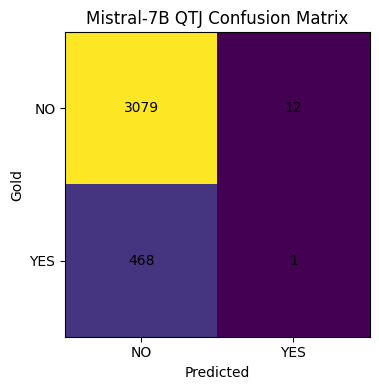

Saved confusion matrix:
/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs_mistral7b/fold_4/mistral7b_confusion_matrix.png


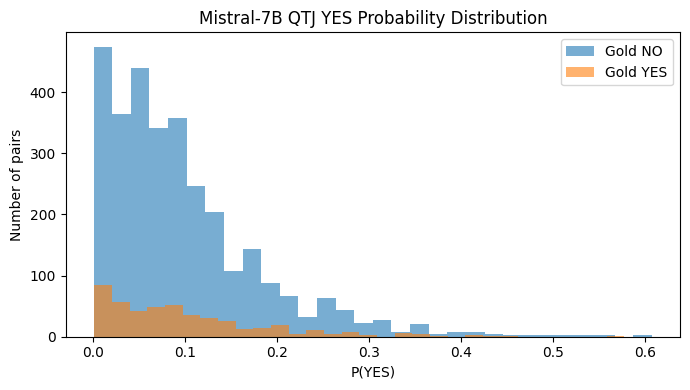

Saved probability plot:
/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs_mistral7b/fold_4/mistral7b_probability_distribution.png

MISTRAL-7B METRICS COMPLETE
Evaluated pairs : 3560
Precision       : 0.0769
Recall          : 0.0021
F1              : 0.0041


In [28]:
# FINAL MISTRAL-7B METRICS CELL
# Loads the saved Mistral predictions, calculates metrics, plots results,
# and saves the metrics outputs.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ---------------------------------------------------------
# PATHS — MISTRAL ONLY
# ---------------------------------------------------------

BASE = Path("/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge")

OUT = BASE / "outputs_mistral7b"
PRED_PATH = OUT / "fold_4" / "mistral7b_qtj_predictions.csv"

print("Loading Mistral predictions from:")
print(PRED_PATH)

assert PRED_PATH.exists(), f"Prediction file not found: {PRED_PATH}"

df = pd.read_csv(PRED_PATH)

print("\nLoaded predictions.")
print("Rows:", len(df))
print("Columns:", df.columns.tolist())


# ---------------------------------------------------------
# IDENTIFY GOLD LABEL COLUMN
# ---------------------------------------------------------

gold_candidates = [
    "gold",
    "label",
    "y_true",
    "true_label",
    "target"
]

gold_col = next(
    (c for c in gold_candidates if c in df.columns),
    None
)

if gold_col is None:
    raise ValueError(
        f"Could not find gold-label column.\n"
        f"Available columns: {df.columns.tolist()}"
    )


# ---------------------------------------------------------
# IDENTIFY PREDICTION COLUMN
# ---------------------------------------------------------

pred_candidates = [
    "pred",
    "prediction",
    "predicted",
    "y_pred",
    "pred_label",
    "predicted_label"
]

pred_col = next(
    (c for c in pred_candidates if c in df.columns),
    None
)

# If there is no prediction column, create it from probability.
if pred_col is None:

    prob_candidates = [
        "p_yes",
        "yes_prob",
        "prob_yes",
        "P_YES",
        "probability_yes"
    ]

    prob_col = next(
        (c for c in prob_candidates if c in df.columns),
        None
    )

    if prob_col is None:
        raise ValueError(
            f"Could not find prediction or YES-probability column.\n"
            f"Available columns: {df.columns.tolist()}"
        )

    print(f"\nNo prediction column found.")
    print(f"Creating predictions from probability column: {prob_col}")

    df["pred"] = (
        pd.to_numeric(df[prob_col], errors="coerce") >= 0.5
    ).astype(int)

    pred_col = "pred"


# ---------------------------------------------------------
# CLEAN LABELS
# ---------------------------------------------------------

df[gold_col] = pd.to_numeric(
    df[gold_col],
    errors="coerce"
)

df[pred_col] = pd.to_numeric(
    df[pred_col],
    errors="coerce"
)

df = df.dropna(
    subset=[gold_col, pred_col]
).copy()

df[gold_col] = df[gold_col].astype(int)
df[pred_col] = df[pred_col].astype(int)


y_true = df[gold_col].values
y_pred = df[pred_col].values


print("\nUsing:")
print("Gold column:", gold_col)
print("Prediction column:", pred_col)
print("Evaluated pairs:", len(df))


# ---------------------------------------------------------
# OVERALL METRICS
# ---------------------------------------------------------

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

print("\n==============================")
print("MISTRAL-7B OVERALL RESULTS")
print("==============================")

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1        : {f1:.4f}")


# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()

print("\nConfusion matrix:")
print(cm)

print(f"\nTN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")


# ---------------------------------------------------------
# PER-DIMENSION METRICS
# ---------------------------------------------------------

if "dim" in df.columns:

    results = []

    for dim in [
        "eric",
        "focus",
        "level",
        "maturity",
        "mechanism"
    ]:

        sub = df[df["dim"] == dim]

        if len(sub) == 0:
            continue

        yt = sub[gold_col].values
        yp = sub[pred_col].values

        results.append({
            "dimension": dim,
            "N": len(sub),
            "positive": int(yt.sum()),
            "precision": precision_score(
                yt, yp, zero_division=0
            ),
            "recall": recall_score(
                yt, yp, zero_division=0
            ),
            "f1": f1_score(
                yt, yp, zero_division=0
            )
        })

    dimension_results = pd.DataFrame(results)

    print("\n==============================")
    print("PER-DIMENSION RESULTS")
    print("==============================")

    print(
        dimension_results.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )

else:

    dimension_results = pd.DataFrame()

    print("\nNo 'dim' column found.")
    print("Skipping per-dimension metrics.")


# ---------------------------------------------------------
# CLASSIFICATION REPORT
# ---------------------------------------------------------

print("\n==============================")
print("CLASSIFICATION REPORT")
print("==============================")

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["NO", "YES"],
        zero_division=0
    )
)


# ---------------------------------------------------------
# SAVE METRICS TABLE
# ---------------------------------------------------------

metrics_summary = pd.DataFrame([{
    "model": "Mistral-7B",
    "gold_column": gold_col,
    "prediction_column": pred_col,
    "N": len(df),
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
}])

metrics_path = OUT / "fold_4" / "mistral7b_qtj_metrics.csv"

metrics_summary.to_csv(
    metrics_path,
    index=False
)

print("\nSaved overall metrics:")
print(metrics_path)


if len(dimension_results) > 0:

    dimension_path = (
        OUT /
        "fold_4" /
        "mistral7b_qtj_dimension_metrics.csv"
    )

    dimension_results.to_csv(
        dimension_path,
        index=False
    )

    print("Saved dimension metrics:")
    print(dimension_path)


# ---------------------------------------------------------
# CONFUSION MATRIX PLOT
# ---------------------------------------------------------

plt.figure(figsize=(5, 4))

plt.imshow(cm)

plt.xticks(
    [0, 1],
    ["NO", "YES"]
)

plt.yticks(
    [0, 1],
    ["NO", "YES"]
)

plt.xlabel("Predicted")
plt.ylabel("Gold")
plt.title("Mistral-7B QTJ Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()

cm_path = OUT / "fold_4" / "mistral7b_confusion_matrix.png"

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved confusion matrix:")
print(cm_path)


# ---------------------------------------------------------
# PROBABILITY HISTOGRAM — IF AVAILABLE
# ---------------------------------------------------------

prob_candidates = [
    "p_yes",
    "yes_prob",
    "prob_yes",
    "P_YES",
    "probability_yes"
]

prob_col = next(
    (c for c in prob_candidates if c in df.columns),
    None
)

if prob_col is not None:

    probs = pd.to_numeric(
        df[prob_col],
        errors="coerce"
    )

    plt.figure(figsize=(7, 4))

    plt.hist(
        probs[df[gold_col] == 0],
        bins=30,
        alpha=0.6,
        label="Gold NO"
    )

    plt.hist(
        probs[df[gold_col] == 1],
        bins=30,
        alpha=0.6,
        label="Gold YES"
    )

    plt.xlabel("P(YES)")
    plt.ylabel("Number of pairs")
    plt.title("Mistral-7B QTJ YES Probability Distribution")
    plt.legend()

    plt.tight_layout()

    hist_path = (
        OUT /
        "fold_4" /
        "mistral7b_probability_distribution.png"
    )

    plt.savefig(
        hist_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved probability plot:")
    print(hist_path)


# ---------------------------------------------------------
# FINAL
# ---------------------------------------------------------

print("\n====================================")
print("MISTRAL-7B METRICS COMPLETE")
print("====================================")
print(f"Evaluated pairs : {len(df)}")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"F1              : {f1:.4f}")

In [29]:
import pandas as pd
import numpy as np

PRED_PATH = "/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs_mistral7b/fold_4/mistral7b_qtj_predictions.csv"

df = pd.read_csv(PRED_PATH)

print("Rows:", len(df))
print("\nColumns:")
print(df.columns.tolist())

print("\nYES probability summary:")
print(df["yes_prob"].describe())

print("\nYES probability by gold label:")
print(
    df.groupby("label")["yes_prob"].describe()
)

print("\nNumber predicted YES at different thresholds:")

for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    print(
        f"threshold {t:.1f}: "
        f"{(df['yes_prob'] >= t).sum()} / {len(df)}"
    )

print("\nHighest 20 YES probabilities:")
print(
    df.nlargest(20, "yes_prob")[
        ["doc_id", "dim", "value", "yes_prob", "label"]
    ].to_string(index=False)
)

print("\nLowest 20 YES probabilities:")
print(
    df.nsmallest(20, "yes_prob")[
        ["doc_id", "dim", "value", "yes_prob", "label"]
    ].to_string(index=False)
)

Rows: 3560

Columns:
['doc_id', 'dim', 'value', 'yes_prob', 'label']

YES probability summary:
count    3560.000000
mean        0.098626
std         0.085659
min         0.001099
25%         0.037327
50%         0.075858
75%         0.132964
max         0.607663
Name: yes_prob, dtype: float64

YES probability by gold label:
        count      mean       std       min       25%       50%       75%  \
label                                                                       
0      3091.0  0.098347  0.085035  0.001099  0.037327  0.075858  0.132964   
1       469.0  0.100465  0.089740  0.001810  0.031144  0.080357  0.140336   

            max  
label            
0      0.607663  
1      0.577495  

Number predicted YES at different thresholds:
threshold 0.1: 1384 / 3560
threshold 0.2: 437 / 3560
threshold 0.3: 114 / 3560
threshold 0.4: 34 / 3560
threshold 0.5: 13 / 3560
threshold 0.6: 1 / 3560
threshold 0.7: 0 / 3560
threshold 0.8: 0 / 3560
threshold 0.9: 0 / 3560

Highest 20 YES proba

In [31]:
# ============================================================
# MISTRAL-7B QTJ — FAIR FIRST-TOKEN BINARY SCORING
# ============================================================

import os
import gc
import time
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

BASE = "/content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge"

MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.3"

LORA_PATH = (
    f"{BASE}/outputs_mistral7b/fold_4/lora_main"
)

PRED_PATH = (
    f"{BASE}/outputs_mistral7b/fold_4/"
    "mistral7b_qtj_predictions_fair.csv"
)

# ------------------------------------------------------------
# Check existing variables
# ------------------------------------------------------------

print("Test pairs:", len(test_pairs))
print("Loading Mistral model...")

# ------------------------------------------------------------
# Load tokenizer/model if necessary
# ------------------------------------------------------------

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

tok = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

if tok.pad_token is None:
    tok.pad_token = tok.eos_token

use_bf16 = torch.cuda.is_bf16_supported()

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=(
        torch.bfloat16 if use_bf16 else torch.float16
    ),
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="sdpa",
)

model = PeftModel.from_pretrained(
    base_model,
    LORA_PATH
)

model.eval()

print("Model loaded.")
print("Adapter:", LORA_PATH)

# ------------------------------------------------------------
# Determine first token for YES / NO
# ------------------------------------------------------------

yes_ids = tok.encode(
    "YES",
    add_special_tokens=False
)

no_ids = tok.encode(
    "NO",
    add_special_tokens=False
)

YES_ID = yes_ids[0]
NO_ID = no_ids[0]

print("YES tokenisation:", yes_ids)
print("NO tokenisation:", no_ids)
print("YES first token:", YES_ID)
print("NO first token:", NO_ID)

# ------------------------------------------------------------
# Prompt
# ------------------------------------------------------------

def make_prompt(p):

    return f"""You are an expert implementation-science coder.

Candidate label:
{p['value']}

Definition:
{p['definition']}

Policy passage:
{p['passage']}

Evidence quote:
{p['evidence']}

Question:
Does the quoted evidence support assigning the candidate label to this passage?

Answer only YES or NO.

Answer:"""

# ------------------------------------------------------------
# Batched first-token scoring
# ------------------------------------------------------------

def score_batch(batch):

    prompts = [
        make_prompt(p)
        for p in batch
    ]

    enc = tok(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=1536,
    )

    input_ids = enc["input_ids"].to(model.device)
    attention_mask = enc["attention_mask"].to(model.device)

    with torch.no_grad():

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        logits = outputs.logits

    # Last real token of each prompt
    last_positions = attention_mask.sum(dim=1) - 1

    row_idx = torch.arange(
        logits.shape[0],
        device=logits.device
    )

    next_logits = logits[
        row_idx,
        last_positions,
        :
    ]

    # Compare first YES token against first NO token
    binary_logits = torch.stack(
        [
            next_logits[:, NO_ID],
            next_logits[:, YES_ID],
        ],
        dim=1
    )

    probs = torch.softmax(
        binary_logits.float(),
        dim=1
    )

    yes_probs = probs[:, 1]

    # IMPORTANT: convert BF16 -> FP32 before NumPy
    return (
        yes_probs
        .float()
        .detach()
        .cpu()
        .numpy()
    )


# ------------------------------------------------------------
# Run inference
# ------------------------------------------------------------

BATCH_SIZE = 8

results = []

start_time = time.time()

for start in tqdm(
    range(0, len(test_pairs), BATCH_SIZE),
    desc="Mistral fair inference"
):

    batch = test_pairs[
        start:start + BATCH_SIZE
    ]

    yes_probs = score_batch(batch)

    for p, prob in zip(batch, yes_probs):

        results.append({
            "doc_id": p["doc"],
            "dim": p["dim"],
            "value": p["value"],
            "yes_prob": float(prob),
            "label": int(p["label"]),
        })

elapsed = time.time() - start_time

df = pd.DataFrame(results)

df.to_csv(
    PRED_PATH,
    index=False
)

print()
print("=" * 60)
print("FAIR MISTRAL INFERENCE COMPLETE")
print("=" * 60)

print("Rows:", len(df))
print(f"Time: {elapsed/60:.2f} minutes")
print("Saved:", PRED_PATH)

print()
print("YES probability summary:")
print(df["yes_prob"].describe())

print()
print("Probability by gold label:")
print(
    df.groupby("label")["yes_prob"].describe()
)

Test pairs: 3560
Loading Mistral model...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Model loaded.
Adapter: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs_mistral7b/fold_4/lora_main
YES tokenisation: [1395, 3023]
NO tokenisation: [8697]
YES first token: 1395
NO first token: 8697


Mistral fair inference:   0%|          | 0/445 [00:00<?, ?it/s]


FAIR MISTRAL INFERENCE COMPLETE
Rows: 3560
Time: 5.56 minutes
Saved: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs_mistral7b/fold_4/mistral7b_qtj_predictions_fair.csv

YES probability summary:
count    3560.000000
mean        0.740955
std         0.128737
min         0.001927
25%         0.718594
50%         0.756897
75%         0.798187
max         0.999364
Name: yes_prob, dtype: float64

Probability by gold label:
        count      mean       std       min       25%       50%       75%  \
label                                                                       
0      3091.0  0.740970  0.129097  0.001927  0.718594  0.760295  0.798187   
1       469.0  0.740855  0.126474  0.002183  0.718594  0.754915  0.798187   

            max  
label            
0      0.999364  
1      0.965381  


In [33]:
# ============================================================
# MISTRAL-7B — THRESHOLD SEARCH + METRICS
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

PRED_PATH = (
    "/content/drive/MyDrive/ERIC_Thesis/"
    "Quote_Then_Judge/outputs_mistral7b/fold_4/"
    "mistral7b_qtj_predictions_fair.csv"
)

df = pd.read_csv(PRED_PATH)

y_true = df["label"].astype(int).values
prob = df["yes_prob"].astype(float).values

print("Rows:", len(df))
print()

# ------------------------------------------------------------
# Basic separation
# ------------------------------------------------------------

print("MEAN P(YES)")
print("Gold NO :", prob[y_true == 0].mean())
print("Gold YES:", prob[y_true == 1].mean())

print()
print(
    "Separation:",
    prob[y_true == 1].mean()
    - prob[y_true == 0].mean()
)

# ------------------------------------------------------------
# Threshold sweep
# ------------------------------------------------------------

rows = []

for threshold in np.arange(
    0.01,
    1.00,
    0.01
):

    pred = (
        prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_true,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        pred,
        zero_division=0
    )

    rows.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "predicted_yes": pred.sum(),
    })

threshold_df = pd.DataFrame(rows)

best = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

print()
print("=" * 60)
print("BEST THRESHOLD")
print("=" * 60)

print(
    "Threshold:",
    round(best["threshold"], 2)
)

print(
    "Precision:",
    round(best["precision"], 4)
)

print(
    "Recall:",
    round(best["recall"], 4)
)

print(
    "F1:",
    round(best["f1"], 4)
)

print(
    "Predicted YES:",
    int(best["predicted_yes"])
)

# ------------------------------------------------------------
# Show top thresholds
# ------------------------------------------------------------

print()
print("TOP 15 THRESHOLDS BY F1:")

print(
    threshold_df
    .sort_values("f1", ascending=False)
    .head(15)
    .to_string(index=False)
)

# ------------------------------------------------------------
# Best-threshold confusion matrix
# ------------------------------------------------------------

best_threshold = float(
    best["threshold"]
)

best_pred = (
    prob >= best_threshold
).astype(int)

cm = confusion_matrix(
    y_true,
    best_pred
)

print()
print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)

print()
print(
    classification_report(
        y_true,
        best_pred,
        target_names=["NO", "YES"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# Per-dimension results
# ------------------------------------------------------------

print()
print("=" * 60)
print("PER-DIMENSION RESULTS")
print("=" * 60)

for dim in [
    "eric",
    "focus",
    "level",
    "maturity",
    "mechanism"
]:

    sub = df[
        df["dim"] == dim
    ]

    yt = sub["label"].astype(int)

    yp = (
        sub["yes_prob"]
        >= best_threshold
    ).astype(int)

    print()
    print(dim.upper())
    print(
        "N:",
        len(sub),
        "| Positives:",
        yt.sum()
    )

    print(
        "Precision:",
        round(
            precision_score(
                yt,
                yp,
                zero_division=0
            ),
            4
        )
    )

    print(
        "Recall:",
        round(
            recall_score(
                yt,
                yp,
                zero_division=0
            ),
            4
        )
    )

    print(
        "F1:",
        round(
            f1_score(
                yt,
                yp,
                zero_division=0
            ),
            4
        )
    )

# ------------------------------------------------------------
# Save threshold results
# ------------------------------------------------------------

threshold_path = (
    "/content/drive/MyDrive/ERIC_Thesis/"
    "Quote_Then_Judge/outputs_mistral7b/fold_4/"
    "mistral7b_fair_thresholds.csv"
)

threshold_df.to_csv(
    threshold_path,
    index=False
)

print()
print("Threshold results saved:")
print(threshold_path)

Rows: 3560

MEAN P(YES)
Gold NO : 0.7409698087713401
Gold YES: 0.740855261993243

Separation: -0.00011454677809707992

BEST THRESHOLD
Threshold: 0.2
Precision: 0.1329
Recall: 0.9872
F1: 0.2342
Predicted YES: 3485

TOP 15 THRESHOLDS BY F1:
 threshold  precision   recall       f1  predicted_yes
      0.20   0.132855 0.987207 0.234193           3485
      0.21   0.132759 0.985075 0.233983           3480
      0.67   0.134281 0.906183 0.233902           3165
      0.19   0.132589 0.987207 0.233779           3492
      0.15   0.132479 0.991471 0.233727           3510
      0.14   0.132441 0.991471 0.233668           3511
      0.16   0.132458 0.989339 0.233635           3503
      0.22   0.132547 0.982942 0.233595           3478
      0.13   0.132365 0.991471 0.233551           3513
      0.18   0.132399 0.987207 0.233485           3497
      0.17   0.132324 0.987207 0.233367           3499
      0.26   0.132429 0.978678 0.233291           3466
      0.12   0.132177 0.991471 0.233258       

In [34]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)

PRED_PATH = (
    "/content/drive/MyDrive/ERIC_Thesis/"
    "Quote_Then_Judge/outputs_mistral7b/fold_4/"
    "mistral7b_qtj_predictions_fair.csv"
)

df = pd.read_csv(PRED_PATH)

# Use the best threshold found above
THRESHOLD = 0.20

df["pred"] = (
    df["yes_prob"] >= THRESHOLD
).astype(int)

# ============================================================
# OVERALL
# ============================================================

y_true = df["label"].astype(int)
y_pred = df["pred"].astype(int)

overall = {
    "dimension": "overall",
    "N": len(df),
    "positive": int(y_true.sum()),
    "precision": precision_score(y_true, y_pred, zero_division=0),
    "recall": recall_score(y_true, y_pred, zero_division=0),
    "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
    "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    "accuracy": accuracy_score(y_true, y_pred),
}

# ============================================================
# PER DIMENSION
# ============================================================

rows = [overall]

for dim in [
    "eric",
    "focus",
    "level",
    "maturity",
    "mechanism",
]:

    sub = df[df["dim"] == dim]

    yt = sub["label"].astype(int)
    yp = sub["pred"].astype(int)

    rows.append({
        "dimension": dim,
        "N": len(sub),
        "positive": int(yt.sum()),

        "precision": precision_score(
            yt, yp, zero_division=0
        ),

        "recall": recall_score(
            yt, yp, zero_division=0
        ),

        "micro_f1": f1_score(
            yt, yp,
            average="micro",
            zero_division=0
        ),

        "macro_f1": f1_score(
            yt, yp,
            average="macro",
            zero_division=0
        ),

        "weighted_f1": f1_score(
            yt, yp,
            average="weighted",
            zero_division=0
        ),

        "accuracy": accuracy_score(
            yt, yp
        ),
    })

results = pd.DataFrame(rows)

# Pretty formatting
display_df = results.copy()

for col in [
    "precision",
    "recall",
    "micro_f1",
    "macro_f1",
    "weighted_f1",
    "accuracy",
]:
    display_df[col] = display_df[col].round(4)

print("=" * 90)
print("MISTRAL-7B QTJ — DIMENSION-WISE RESULTS")
print("=" * 90)
print(f"Threshold: {THRESHOLD}")
print()

print(
    display_df.to_string(index=False)
)

# ============================================================
# SAVE
# ============================================================

RESULT_PATH = (
    "/content/drive/MyDrive/ERIC_Thesis/"
    "Quote_Then_Judge/outputs_mistral7b/fold_4/"
    "mistral7b_dimension_results.csv"
)

results.to_csv(
    RESULT_PATH,
    index=False
)

print()
print("Saved:", RESULT_PATH)

MISTRAL-7B QTJ — DIMENSION-WISE RESULTS
Threshold: 0.2

dimension    N  positive  precision  recall  micro_f1  macro_f1  weighted_f1  accuracy
  overall 3560       469     0.1329  0.9872    0.1494    0.1389       0.0687    0.1494
     eric 2920       315     0.1086  0.9873    0.1247    0.1178       0.0566    0.1247
    focus  280        41     0.1487  0.9756    0.1786    0.1690       0.1061    0.1786
    level  120        40     0.3390  1.0000    0.3500    0.2776       0.2013    0.3500
 maturity  120        40     0.3362  0.9750    0.3500    0.2857       0.2143    0.3500
mechanism  120        33     0.2773  1.0000    0.2833    0.2285       0.1359    0.2833

Saved: /content/drive/MyDrive/ERIC_Thesis/Quote_Then_Judge/outputs_mistral7b/fold_4/mistral7b_dimension_results.csv


In [35]:
# ============================================================
# CELL — TRAIN-ALIGNED QTJ GENERATION EVALUATION
# ============================================================

from tqdm.auto import tqdm
import torch
import time
import re

model.eval()

predictions_generation = []

t0 = time.time()

# Generate the SAME target format used during training:
# EVIDENCE: <quote or NONE>
# ANSWER: <YES or NO>

for start in tqdm(
    range(0, len(test_pairs), BATCH_SIZE),
    desc="Generating QTJ answers",
):

    batch = test_pairs[start:start + BATCH_SIZE]

    # IMPORTANT:
    # Use exactly the training prompt.
    prompts = [
        build_evidence_prompt(p)
        for p in batch
    ]

    inputs = tok(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_SEQ,
    )

    inputs = {
        k: v.to(model.device)
        for k, v in inputs.items()
    }

    with torch.inference_mode():

        generated = model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False,
            num_beams=1,
            pad_token_id=tok.pad_token_id,
            eos_token_id=tok.eos_token_id,
        )

    # Remove original prompt tokens
    prompt_lengths = inputs["attention_mask"].sum(dim=1)

    for i, p in enumerate(batch):

        gen_tokens = generated[i, prompt_lengths[i]:]

        text = tok.decode(
            gen_tokens,
            skip_special_tokens=True
        ).strip()

        # ----------------------------------------------------
        # Extract ANSWER from generated training target
        # ----------------------------------------------------

        answer_match = re.search(
            r"ANSWER\s*:\s*(YES|NO)",
            text,
            flags=re.IGNORECASE
        )

        if answer_match:
            answer = answer_match.group(1).upper()
        else:
            # fallback: look for final YES/NO
            yes_no = re.findall(
                r"\b(YES|NO)\b",
                text.upper()
            )

            answer = (
                yes_no[-1]
                if yes_no
                else "NO"
            )

        pred = 1 if answer == "YES" else 0

        predictions_generation.append({
            "doc_id": p["doc"],
            "dim": p["dim"],
            "value": p["value"],
            "label": int(p["label"]),
            "prediction": pred,
            "answer": answer,
            "generated_text": text,
        })

    del inputs, generated

    if start % (BATCH_SIZE * 10) == 0:
        torch.cuda.empty_cache()

print()
print("=" * 90)
print("TRAIN-ALIGNED GENERATION COMPLETE")
print("=" * 90)
print(f"Time: {(time.time()-t0)/60:.1f} min")
print("Predictions:", len(predictions_generation))

# Show a few generated examples
for x in predictions_generation[:5]:
    print("\n-----------------------------")
    print("Gold:", "YES" if x["label"] else "NO")
    print("Pred:", x["answer"])
    print("Generated:")
    print(x["generated_text"][:1000])

Generating QTJ answers:   0%|          | 0/445 [00:00<?, ?it/s]

[transformers] A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
[transformers] A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
[transformers] A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
[transformers] A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
[transformers] A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
[transformers] A decoder-only architecture is being used, bu


TRAIN-ALIGNED GENERATION COMPLETE
Time: 99.1 min
Predictions: 3560

-----------------------------
Gold: NO
Pred: NO
Generated:
�sion of IPC program in all 
health care facilities 
 
 Develop and implement national IPC standards 
 Develop and implement national IPC standards 
 Develop and implement national IPC 
standards for all health care 
facilities 
 Develop and implement national IPC 
 Develop and implement national IPC 
standards for all health care facilities
3.1.1: Establishment of IPC program in all medical colleges
 Establishment of IPC program in all 
 Establishment of IPC program in all 


-----------------------------
Gold: YES
Pred: NO
Generated:
��28 
policy document 
 Conduct regular training on AMR for human health professionals 
Number of training on AMR conducted for human health 
professionals 
 Conduct regular review meeting of the 
platform 
 Conduct review meeting of the platform 
Number of review meeting of the platform 
platform) 
DCU, DCU, DGHS, DG

In [36]:
# ============================================================
# CELL — FULL DIMENSION-WISE QTJ METRICS
# ============================================================

import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
)

rows = []

DIMENSIONS = [
    "eric",
    "focus",
    "level",
    "maturity",
    "mechanism",
]

# ------------------------------------------------------------
# Overall
# ------------------------------------------------------------

yt = [
    x["label"]
    for x in predictions_generation
]

yp = [
    x["prediction"]
    for x in predictions_generation
]

rows.append({
    "dimension": "overall",
    "N": len(yt),
    "positive": sum(yt),

    "micro_precision": precision_score(
        yt, yp, average="micro", zero_division=0
    ),
    "micro_recall": recall_score(
        yt, yp, average="micro", zero_division=0
    ),
    "micro_f1": f1_score(
        yt, yp, average="micro", zero_division=0
    ),

    "macro_precision": precision_score(
        yt, yp, average="macro", zero_division=0
    ),
    "macro_recall": recall_score(
        yt, yp, average="macro", zero_division=0
    ),
    "macro_f1": f1_score(
        yt, yp, average="macro", zero_division=0
    ),

    "weighted_f1": f1_score(
        yt, yp, average="weighted", zero_division=0
    ),

    "accuracy": accuracy_score(
        yt, yp
    ),
})

# ------------------------------------------------------------
# Each dimension
# ------------------------------------------------------------

for dim in DIMENSIONS:

    sub = [
        x for x in predictions_generation
        if x["dim"].lower() == dim
    ]

    yt = [x["label"] for x in sub]
    yp = [x["prediction"] for x in sub]

    rows.append({
        "dimension": dim,
        "N": len(yt),
        "positive": sum(yt),

        "micro_precision": precision_score(
            yt, yp,
            average="micro",
            zero_division=0
        ),

        "micro_recall": recall_score(
            yt, yp,
            average="micro",
            zero_division=0
        ),

        "micro_f1": f1_score(
            yt, yp,
            average="micro",
            zero_division=0
        ),

        "macro_precision": precision_score(
            yt, yp,
            average="macro",
            zero_division=0
        ),

        "macro_recall": recall_score(
            yt, yp,
            average="macro",
            zero_division=0
        ),

        "macro_f1": f1_score(
            yt, yp,
            average="macro",
            zero_division=0
        ),

        "weighted_f1": f1_score(
            yt, yp,
            average="weighted",
            zero_division=0
        ),

        "accuracy": accuracy_score(
            yt, yp
        ),
    })

results_generation = pd.DataFrame(rows)

# Round
for c in results_generation.columns:
    if c not in ["dimension", "N", "positive"]:
        results_generation[c] = results_generation[c].round(4)

print()
print("=" * 120)
print("MISTRAL-7B QTJ — TRAIN-ALIGNED GENERATION RESULTS")
print("=" * 120)

print(
    results_generation.to_string(index=False)
)

# ------------------------------------------------------------
# Confusion matrices
# ------------------------------------------------------------

print()
print("=" * 70)
print("CONFUSION MATRICES")
print("=" * 70)

for dim in ["overall"] + DIMENSIONS:

    if dim == "overall":
        sub = predictions_generation
    else:
        sub = [
            x for x in predictions_generation
            if x["dim"].lower() == dim
        ]

    yt = [x["label"] for x in sub]
    yp = [x["prediction"] for x in sub]

    cm = confusion_matrix(
        yt,
        yp,
        labels=[0, 1]
    )

    print(f"\n{dim.upper()}")
    print("              Pred NO   Pred YES")
    print(f"Gold NO       {cm[0,0]:8d}   {cm[0,1]:8d}")
    print(f"Gold YES      {cm[1,0]:8d}   {cm[1,1]:8d}")

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

RESULT_PATH = (
    "/content/drive/MyDrive/ERIC_Thesis/"
    "Quote_Then_Judge/outputs_mistral7b/fold_4/"
    "mistral7b_qtj_train_aligned_results.csv"
)

results_generation.to_csv(
    RESULT_PATH,
    index=False
)

# Also save individual generated predictions
PRED_PATH = (
    "/content/drive/MyDrive/ERIC_Thesis/"
    "Quote_Then_Judge/outputs_mistral7b/fold_4/"
    "mistral7b_qtj_train_aligned_predictions.csv"
)

pd.DataFrame(
    predictions_generation
).to_csv(
    PRED_PATH,
    index=False
)

print()
print("Results saved:", RESULT_PATH)
print("Predictions saved:", PRED_PATH)


MISTRAL-7B QTJ — TRAIN-ALIGNED GENERATION RESULTS
dimension    N  positive  micro_precision  micro_recall  micro_f1  macro_precision  macro_recall  macro_f1  weighted_f1  accuracy
  overall 3560       469           0.8444        0.8444    0.8444           0.4641        0.4917    0.4683       0.7977    0.8444
     eric 2920       315           0.8661        0.8661    0.8661           0.4744        0.4924    0.4765       0.8307    0.8661
    focus  280        41           0.8321        0.8321    0.8321           0.4252        0.4874    0.4542       0.7754    0.8321
    level  120        40           0.6500        0.6500    0.6500           0.3305        0.4875    0.3939       0.5253    0.6500
 maturity  120        40           0.6583        0.6583    0.6583           0.5000        0.5000    0.4192       0.5434    0.6583
mechanism  120        33           0.7250        0.7250    0.7250           0.3625        0.5000    0.4203       0.6094    0.7250

CONFUSION MATRICES

OVERALL
          